# MarketMind AI — Small Business Sales Intelligence Platform
## Milestone 1: Data Preparation & Preprocessing

**Dataset:** Online Retail II (UCI Machine Learning Repository / Kaggle: `dvaser/online-retail-ii`)
**Scope:** This notebook covers data preparation ONLY. No ML models, forecasting, segmentation,
anomaly detection, churn prediction, or deployment are performed here — those belong to later milestones.

**Pipeline stages:**
1. Load Dataset
2. Data Quality Analysis
3. Data Cleaning
4. Feature Engineering
5. Inventory Dataset Preparation
6. Customer Dataset Preparation
7. Exploratory Data Analysis (EDA)
8. Export Processed Data


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13

RAW_PATH = "../data/raw/online_retail_II.csv"
PROCESSED_DIR = "../data/processed"
CHARTS_DIR = "../charts"
REPORTS_DIR = "../reports"

PALETTE = ["#6C63FF", "#00C2CC", "#FF6584", "#FFC85C", "#4ADE80", "#38BDF8", "#A78BFA", "#F472B6"]


## 1. Load Dataset

The raw dataset is the full **Online Retail II** transaction log (Dec 2009 – Dec 2011) for a
UK-based online gift retailer, containing 1,067,371 rows and 8 columns.

In [2]:
df_raw = pd.read_csv(RAW_PATH, parse_dates=["InvoiceDate"])
print("Shape:", df_raw.shape)
df_raw.head()

Shape: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12.0,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12.0,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12.0,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48.0,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24.0,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
df_raw.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6.0,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4.0,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4.0,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3.0,2011-12-09 12:50:00,4.95,12680.0,France
1067370,581587,POST,POSTAGE,1.0,2011-12-09 12:50:00,18.00,12680.0,France


In [4]:
print("Columns:", list(df_raw.columns))
df_raw.info()

Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'CustomerID', 'Country']
<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  str           
 1   StockCode    1067371 non-null  str           
 2   Description  1062989 non-null  str           
 3   Quantity     1067371 non-null  float64       
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   CustomerID   824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(3), str(4)
memory usage: 65.1 MB


In [5]:
df_raw.describe()

,Quantity,InvoiceDate,Price,CustomerID
count,1.067371e+06,1067371,1.067371e+06,824364.000000
mean,9.938898e+00,2011-01-02 21:13:55.394029,4.649388e+00,15324.638504
min,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000
25%,1.000000e+00,2010-07-09 09:46:00,1.250000e+00,13975.000000
50%,3.000000e+00,2010-12-07 15:28:00,2.100000e+00,15255.000000
75%,1.000000e+01,2011-07-22 10:23:00,4.150000e+00,16797.000000
max,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000
std,1.727058e+02,NaN,1.235531e+02,1697.464450


In [6]:
df_raw.describe(include="object")

,Invoice,StockCode,Description,Country
count,1067371,1067371,1062989,1067371
unique,53628,5304,5655,43
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,1350,5829,5918,981330


## 2. Data Quality Analysis

We check for missing values, duplicates, incorrect types, negative quantities/prices,
cancelled invoices, invalid `CustomerID`s, and empty descriptions.

In [7]:
quality_report = {}
quality_report["total_rows"] = len(df_raw)
quality_report["total_columns"] = df_raw.shape[1]

missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_df = missing_df[missing_df["missing_count"] > 0]
missing_df

,missing_count,missing_pct
Description,4382,0.41
CustomerID,243007,22.77


In [8]:
dup_count = df_raw.duplicated().sum()
print("Duplicate rows:", dup_count)

Duplicate rows: 34335


In [9]:
neg_qty = (df_raw["Quantity"] < 0).sum()
neg_price = (df_raw["Price"] < 0).sum()
zero_price = (df_raw["Price"] == 0).sum()
cancelled = df_raw["Invoice"].astype(str).str.startswith("C").sum()
invalid_customer = df_raw["CustomerID"].isnull().sum()
empty_desc = df_raw["Description"].isnull().sum()

print(f"Negative quantities   : {neg_qty:,}")
print(f"Negative prices       : {neg_price:,}")
print(f"Zero prices           : {zero_price:,}")
print(f"Cancelled invoices    : {cancelled:,}")
print(f"Missing CustomerID    : {invalid_customer:,}")
print(f"Empty descriptions    : {empty_desc:,}")

Negative quantities   : 22,950
Negative prices       : 5
Zero prices           : 6,202
Cancelled invoices    : 19,494
Missing CustomerID    : 243,007
Empty descriptions    : 4,382


In [10]:
# Persist a written data quality report
quality_lines = [
    "# Data Quality Report -- Online Retail II\n",
    f"- Total rows: {len(df_raw):,}",
    f"- Total columns: {df_raw.shape[1]}",
    f"- Duplicate rows: {dup_count:,}",
    f"- Negative quantities (returns): {neg_qty:,}",
    f"- Negative unit prices: {neg_price:,}",
    f"- Zero unit prices: {zero_price:,}",
    f"- Cancelled invoices (Invoice starts with 'C'): {cancelled:,}",
    f"- Rows with missing CustomerID: {invalid_customer:,}",
    f"- Empty/missing product descriptions: {empty_desc:,}",
    "\n## Missing values by column\n",
    missing_df.to_markdown(),
]
with open(f"{REPORTS_DIR}/data_quality_report.md", "w") as f:
    f.write("\n".join(quality_lines))
print("Saved reports/data_quality_report.md")

Saved reports/data_quality_report.md


## 3. Data Cleaning

Each cleaning step is applied sequentially and logged, so the effect of every rule on row count
is traceable.

> **Note on columns:** the real Online Retail II schema uses `Invoice`, `Price`, and `CustomerID`
> (rather than `InvoiceNo` / `UnitPrice`), so those exact column names are used throughout.

In [11]:
cleaning_log = []
df = df_raw.copy()
cleaning_log.append(f"Starting rows: {len(df):,}")

# Remove exact duplicate rows
before = len(df)
df = df.drop_duplicates()
cleaning_log.append(f"Removed {before - len(df):,} duplicate rows -> {len(df):,} remaining")

# Remove cancelled invoices (Invoice starting with 'C')
before = len(df)
df = df[~df["Invoice"].astype(str).str.startswith("C")]
cleaning_log.append(f"Removed {before - len(df):,} cancelled invoice rows -> {len(df):,} remaining")

# Remove rows with missing CustomerID
before = len(df)
df = df.dropna(subset=["CustomerID"])
cleaning_log.append(f"Removed {before - len(df):,} rows with missing CustomerID -> {len(df):,} remaining")

# Remove invalid quantities (<= 0)
before = len(df)
df = df[df["Quantity"] > 0]
cleaning_log.append(f"Removed {before - len(df):,} rows with quantity <= 0 -> {len(df):,} remaining")

# Remove invalid prices (<= 0)
before = len(df)
df = df[df["Price"] > 0]
cleaning_log.append(f"Removed {before - len(df):,} rows with price <= 0 -> {len(df):,} remaining")

for line in cleaning_log:
    print(line)

Starting rows: 1,067,371
Removed 34,335 duplicate rows -> 1,033,036 remaining
Removed 19,104 cancelled invoice rows -> 1,013,932 remaining
Removed 234,437 rows with missing CustomerID -> 779,495 remaining
Removed 0 rows with quantity <= 0 -> 779,495 remaining
Removed 70 rows with price <= 0 -> 779,425 remaining


In [12]:
# Handle missing descriptions: fill via StockCode lookup, fallback to 'UNKNOWN PRODUCT'
before_missing = df["Description"].isnull().sum()

desc_lookup = (
    df.dropna(subset=["Description"])
    .groupby("StockCode")["Description"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)
df["Description"] = df.apply(
    lambda r: desc_lookup.get(r["StockCode"], np.nan) if pd.isnull(r["Description"]) else r["Description"],
    axis=1,
)
df["Description"] = df["Description"].fillna("UNKNOWN PRODUCT").str.strip()

cleaning_log.append(f"Filled {before_missing:,} missing descriptions (StockCode lookup, fallback 'UNKNOWN PRODUCT')")
print(f"Filled {before_missing:,} missing descriptions")

Filled 0 missing descriptions


In [13]:
# Correct data types & reset index
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["CustomerID"] = df["CustomerID"].astype(int).astype(str)
df["Invoice"] = df["Invoice"].astype(str)
df["StockCode"] = df["StockCode"].astype(str)
df = df.reset_index(drop=True)

cleaning_log.append("Confirmed InvoiceDate as datetime64 dtype")
cleaning_log.append("Cast CustomerID/Invoice/StockCode to string types (CustomerID as clean integer-string ID)")
cleaning_log.append(f"Index reset. Final clean row count: {len(df):,}")

with open(f"{REPORTS_DIR}/cleaning_log.md", "w") as f:
    f.write("# Data Cleaning Log\n\n" + "\n".join(f"- {l}" for l in cleaning_log))

print(f"Final clean dataset shape: {df.shape}")

Final clean dataset shape: (779425, 8)


## 4. Feature Engineering

Business-relevant features are derived. **No prediction labels or targets are created** —
this is strictly feature preparation for later milestones.

In [14]:
df["Revenue"] = df["Quantity"] * df["Price"]

df["OrderYear"] = df["InvoiceDate"].dt.year
df["OrderMonth"] = df["InvoiceDate"].dt.month
df["OrderDay"] = df["InvoiceDate"].dt.day
df["DayOfWeek"] = df["InvoiceDate"].dt.day_name()
df["WeekNumber"] = df["InvoiceDate"].dt.isocalendar().week.astype(int)
df["Quarter"] = df["InvoiceDate"].dt.quarter
df["MonthName"] = df["InvoiceDate"].dt.month_name()
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M").astype(str)

cust_orders = df.groupby("CustomerID")["Invoice"].nunique()
cust_spend = df.groupby("CustomerID")["Revenue"].sum()

df["CustomerPurchaseFrequency"] = df["CustomerID"].map(cust_orders)
df["CustomerTotalSpend"] = df["CustomerID"].map(cust_spend)
df["AverageOrderValue"] = (df["CustomerTotalSpend"] / df["CustomerPurchaseFrequency"]).round(2)

df[["Invoice","StockCode","Quantity","Price","Revenue","OrderYear","OrderMonth",
    "DayOfWeek","Quarter","CustomerPurchaseFrequency","CustomerTotalSpend","AverageOrderValue"]].head()

,Invoice,StockCode,Quantity,Price,Revenue,OrderYear,OrderMonth,DayOfWeek,Quarter,CustomerPurchaseFrequency,CustomerTotalSpend,AverageOrderValue
0,489434,85048,12.0,6.95,83.4,2009,12,Tuesday,4,8,2433.28,304.16
1,489434,79323P,12.0,6.75,81.0,2009,12,Tuesday,4,8,2433.28,304.16
2,489434,79323W,12.0,6.75,81.0,2009,12,Tuesday,4,8,2433.28,304.16
3,489434,22041,48.0,2.10,100.8,2009,12,Tuesday,4,8,2433.28,304.16
4,489434,21232,24.0,1.25,30.0,2009,12,Tuesday,4,8,2433.28,304.16


## 5. Inventory Dataset Preparation

Aggregates every transaction line up to product level.

In [15]:
inventory_df = (
    df.groupby(["StockCode", "Description"])
    .agg(
        QuantitySold=("Quantity", "sum"),
        Revenue=("Revenue", "sum"),
        SalesFrequency=("Invoice", "nunique"),
    )
    .reset_index()
)
inventory_df["AverageSellingPrice"] = (inventory_df["Revenue"] / inventory_df["QuantitySold"]).round(2)

# Product demand score: min-max normalized quantity sold (0-100), a descriptive ranking metric only
inventory_df["ProductDemandScore"] = (
    (inventory_df["QuantitySold"] - inventory_df["QuantitySold"].min())
    / (inventory_df["QuantitySold"].max() - inventory_df["QuantitySold"].min())
    * 100
).round(2)

inventory_df = inventory_df.rename(columns={"StockCode": "ProductCode", "Description": "ProductName"})
inventory_df = inventory_df[
    ["ProductCode", "ProductName", "QuantitySold", "Revenue",
     "AverageSellingPrice", "ProductDemandScore", "SalesFrequency"]
]
inventory_df = inventory_df.sort_values("Revenue", ascending=False).reset_index(drop=True)

print("Inventory dataset shape:", inventory_df.shape)
inventory_df.head(10)

Inventory dataset shape: (5286, 7)


,ProductCode,ProductName,QuantitySold,Revenue,AverageSellingPrice,ProductDemandScore,SalesFrequency
0,22423,REGENCY CAKESTAND 3 TIER,24124.0,277656.25,11.51,22.93,3317
1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,91757.0,247048.01,2.69,87.23,4888
2,23843,"PAPER CRAFT , LITTLE BIRDIE",80995.0,168469.60,2.08,77.00,1
3,M,Manual,9384.0,151777.67,16.17,8.92,620
4,85099B,JUMBO BAG RED RETROSPOT,74224.0,134307.44,1.81,70.56,2612
5,POST,POSTAGE,5235.0,124648.04,23.81,4.98,1803
6,84879,ASSORTED COLOUR BIRD ORNAMENT,78234.0,124351.86,1.59,74.38,2652
7,47566,PARTY BUNTING,23460.0,103283.38,4.40,22.30,2077
8,23166,MEDIUM CERAMIC TOP STORAGE JAR,77916.0,81416.73,1.04,74.07,195
9,22086,PAPER CHAIN KIT 50'S CHRISTMAS,28380.0,76598.18,2.70,26.98,1691


## 6. Customer Dataset Preparation

Aggregates every transaction line up to customer level.

In [16]:
customer_df = (
    df.groupby("CustomerID")
    .agg(
        TotalOrders=("Invoice", "nunique"),
        TotalRevenue=("Revenue", "sum"),
        NumberOfPurchasedProducts=("StockCode", "nunique"),
        Country=("Country", lambda x: x.mode().iloc[0]),
    )
    .reset_index()
)
customer_df["AverageSpending"] = (customer_df["TotalRevenue"] / customer_df["TotalOrders"]).round(2)
customer_df["PurchaseFrequency"] = customer_df["TotalOrders"]

customer_df = customer_df[
    ["CustomerID", "TotalOrders", "TotalRevenue", "AverageSpending",
     "NumberOfPurchasedProducts", "PurchaseFrequency", "Country"]
]
customer_df = customer_df.sort_values("TotalRevenue", ascending=False).reset_index(drop=True)

print("Customer dataset shape:", customer_df.shape)
customer_df.head(10)

Customer dataset shape: (5878, 7)


,CustomerID,TotalOrders,TotalRevenue,AverageSpending,NumberOfPurchasedProducts,PurchaseFrequency,Country
0,18102,145,580987.04,4006.81,382,145,United Kingdom
1,14646,151,528602.52,3500.68,961,151,Netherlands
2,14156,156,313437.62,2009.22,1446,156,EIRE
3,14911,398,291420.81,732.21,2550,398,EIRE
4,17450,51,244784.25,4799.69,144,51,United Kingdom
5,13694,143,195640.69,1368.12,896,143,United Kingdom
6,17511,60,172132.87,2868.88,657,60,United Kingdom
7,16446,2,168472.50,84236.25,3,2,United Kingdom
8,16684,55,147142.77,2675.32,184,55,United Kingdom
9,12415,28,144458.37,5159.23,498,28,Australia


## 7. Exploratory Data Analysis

Eight professional visualizations covering trend, ranking, geography, and distribution views.

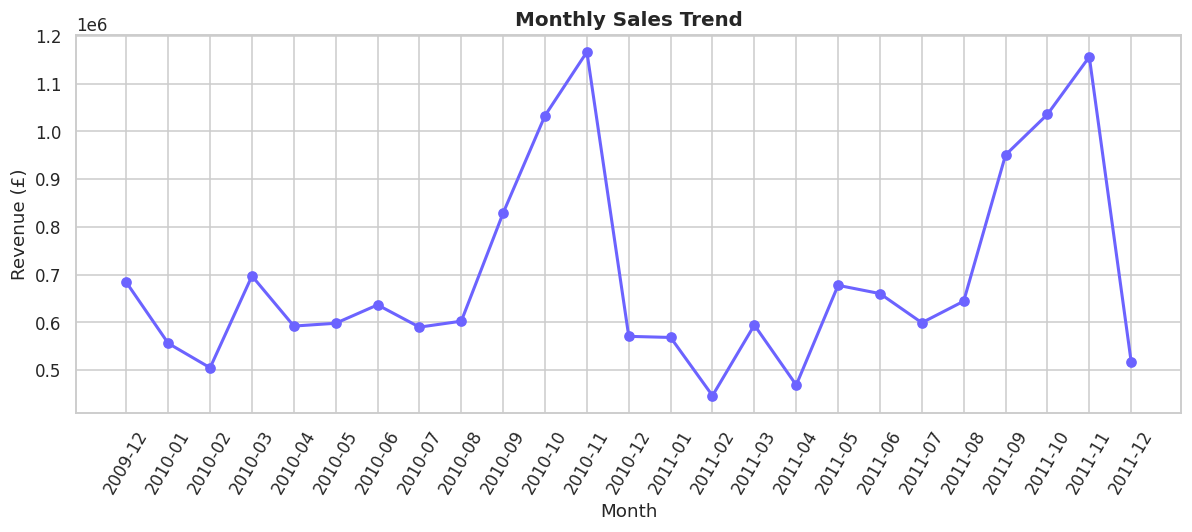

In [17]:
monthly_sales = df.groupby("YearMonth")["Revenue"].sum().reset_index()
plt.figure(figsize=(11, 5))
plt.plot(monthly_sales["YearMonth"], monthly_sales["Revenue"], marker="o", color=PALETTE[0], linewidth=2)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=60)
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/01_monthly_sales_trend.png")
plt.show()

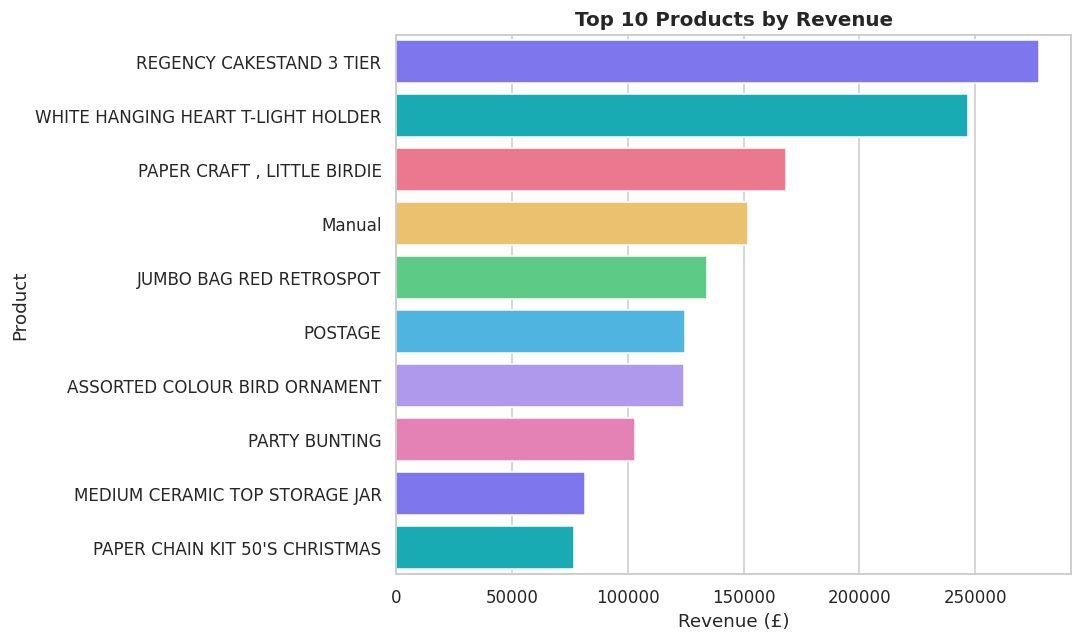

In [18]:
top_products = inventory_df.nlargest(10, "Revenue")
plt.figure(figsize=(10, 6))
sns.barplot(data=top_products, y="ProductName", x="Revenue", palette=PALETTE)
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Product")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/02_top_10_products.png")
plt.show()

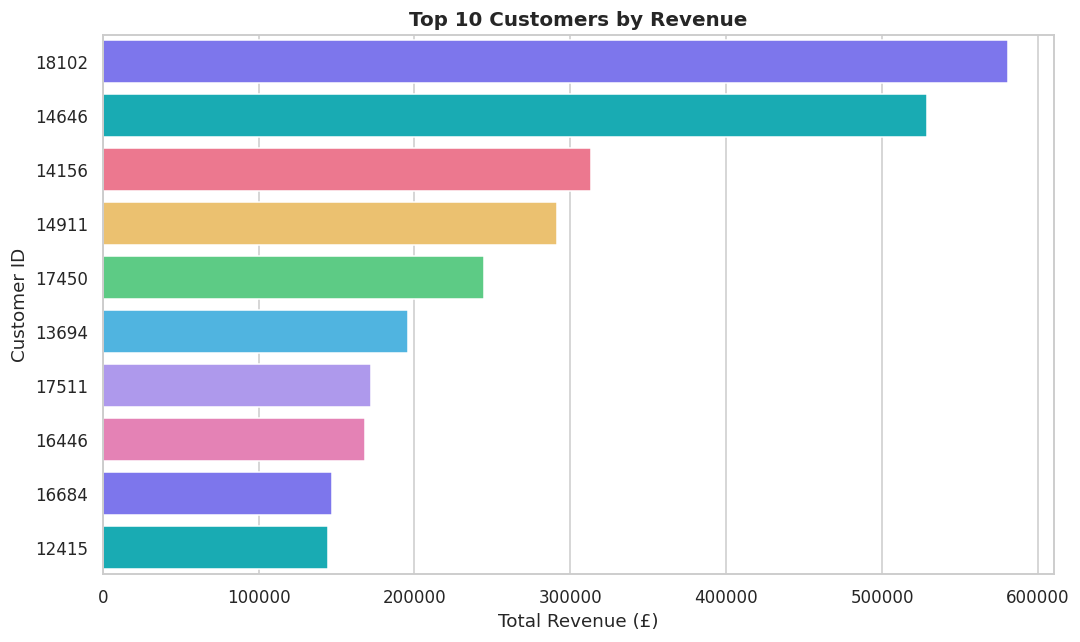

In [19]:
top_customers = customer_df.nlargest(10, "TotalRevenue")
plt.figure(figsize=(10, 6))
sns.barplot(data=top_customers, y="CustomerID", x="TotalRevenue", order=top_customers["CustomerID"], palette=PALETTE)
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Total Revenue (£)")
plt.ylabel("Customer ID")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/03_top_10_customers.png")
plt.show()

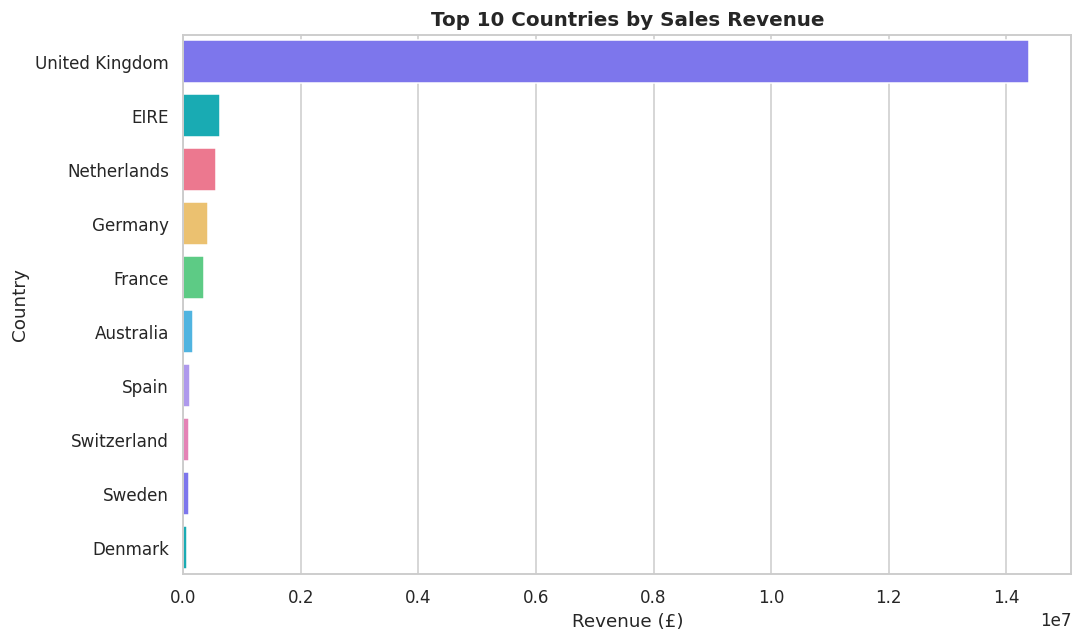

In [20]:
country_sales = df.groupby("Country")["Revenue"].sum().nlargest(10).reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=country_sales, y="Country", x="Revenue", palette=PALETTE)
plt.title("Top 10 Countries by Sales Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/04_country_wise_sales.png")
plt.show()

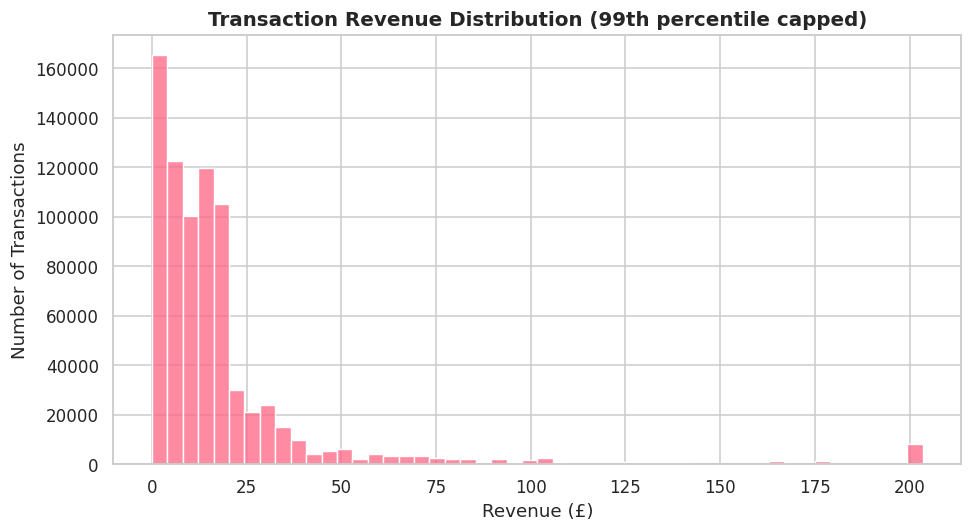

In [21]:
plt.figure(figsize=(9, 5))
capped_revenue = df["Revenue"].clip(upper=df["Revenue"].quantile(0.99))
sns.histplot(capped_revenue, bins=50, color=PALETTE[2])
plt.title("Transaction Revenue Distribution (99th percentile capped)")
plt.xlabel("Revenue (£)")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/05_revenue_distribution.png")
plt.show()

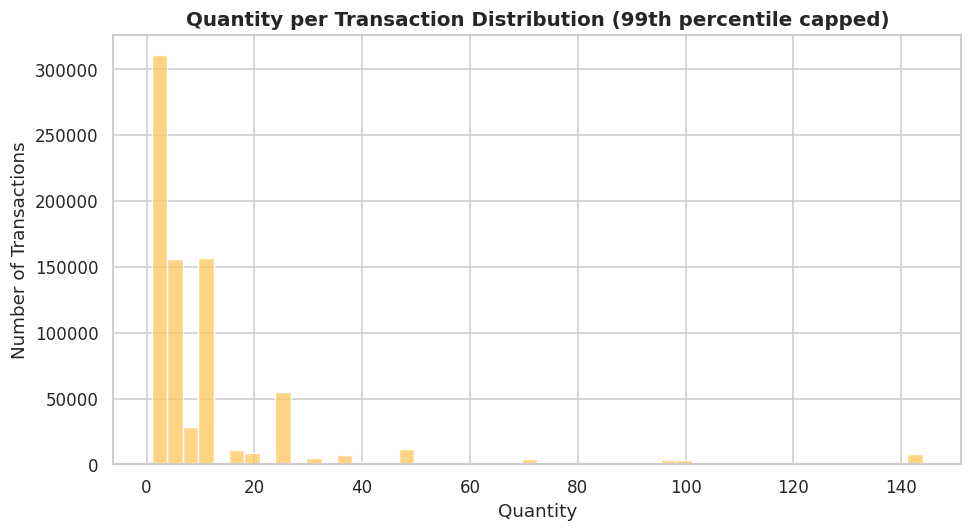

In [22]:
plt.figure(figsize=(9, 5))
capped_qty = df["Quantity"].clip(upper=df["Quantity"].quantile(0.99))
sns.histplot(capped_qty, bins=50, color=PALETTE[3])
plt.title("Quantity per Transaction Distribution (99th percentile capped)")
plt.xlabel("Quantity")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/06_quantity_distribution.png")
plt.show()

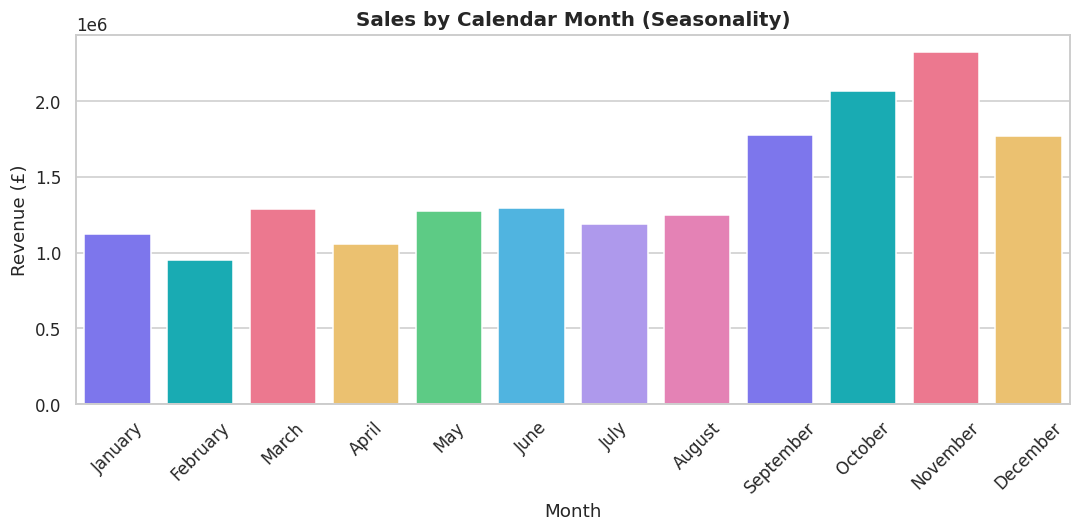

In [23]:
month_order = ["January","February","March","April","May","June","July",
               "August","September","October","November","December"]
sales_by_month = df.groupby("MonthName")["Revenue"].sum().reindex(month_order).reset_index()
plt.figure(figsize=(10, 5))
sns.barplot(data=sales_by_month, x="MonthName", y="Revenue", palette=PALETTE)
plt.title("Sales by Calendar Month (Seasonality)")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/07_sales_by_month.png")
plt.show()

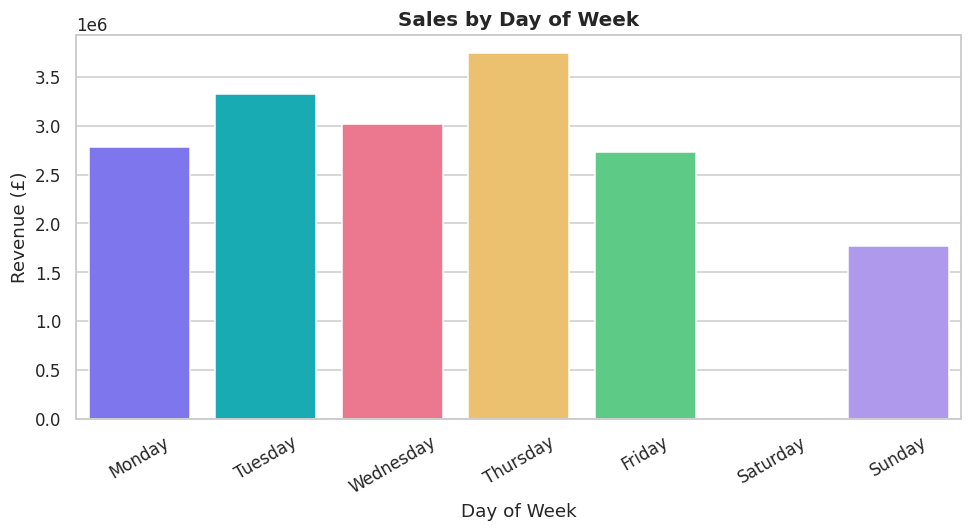

In [24]:
weekday_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
sales_by_weekday = df.groupby("DayOfWeek")["Revenue"].sum().reindex(weekday_order).reset_index()
plt.figure(figsize=(9, 5))
sns.barplot(data=sales_by_weekday, x="DayOfWeek", y="Revenue", palette=PALETTE)
plt.title("Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/08_sales_by_weekday.png")
plt.show()

## 8. Export Processed Data

Three AI-ready datasets are exported to `data/processed/` for use in later milestones.

In [25]:
export_cols = [
    "Invoice", "StockCode", "Description", "Quantity", "Price", "Revenue",
    "InvoiceDate", "OrderYear", "OrderMonth", "OrderDay", "DayOfWeek",
    "WeekNumber", "Quarter", "MonthName", "YearMonth",
    "CustomerID", "Country",
    "CustomerPurchaseFrequency", "CustomerTotalSpend", "AverageOrderValue",
]
df_export = df[export_cols]

df_export.to_csv(f"{PROCESSED_DIR}/clean_transactions.csv", index=False)
inventory_df.to_csv(f"{PROCESSED_DIR}/inventory_dataset.csv", index=False)
customer_df.to_csv(f"{PROCESSED_DIR}/customer_dataset.csv", index=False)

print("Exported:")
print(f" - clean_transactions.csv : {df_export.shape}")
print(f" - inventory_dataset.csv  : {inventory_df.shape}")
print(f" - customer_dataset.csv   : {customer_df.shape}")

Exported:
 - clean_transactions.csv : (779425, 20)
 - inventory_dataset.csv  : (5286, 7)
 - customer_dataset.csv   : (5878, 7)


## Summary

Milestone 1 is complete. Three clean, AI-ready datasets have been produced from the raw
Online Retail II transaction log:

| File | Rows | Description |
|---|---|---|
| `clean_transactions.csv` | ~779K | Cleaned, feature-enriched transaction-level data |
| `inventory_dataset.csv` | ~5.3K | Product-level aggregates for inventory/demand analysis |
| `customer_dataset.csv` | ~5.9K | Customer-level aggregates for customer analytics |

No modeling, forecasting, or segmentation was performed — these datasets are prepared
inputs for future AI/ML milestones. See `reports/preprocessing_report.md` for full documentation.


---
# Milestone 1 — Extended Business Intelligence Report

The sections below extend the preprocessing work above with an executive summary,
a formal data quality report, KPI reporting, missing-value and correlation diagnostics,
a dataset-readiness summary, business insights, an export confirmation, the recommended
project structure, and a closing conclusion.

**Scope reminder:** everything below is descriptive analytics and data preparation only.
No machine learning models, forecasting, recommendation systems, clustering/segmentation,
anomaly detection, or churn prediction are performed in this notebook.


## A. Executive Summary

A high-level snapshot of the dataset used for this milestone, before and after cleaning.

In [26]:
# Executive summary metrics
exec_summary_df = pd.DataFrame(
    {
        "Metric": [
            "Dataset Name",
            "Total Records (raw)",
            "Total Records (clean)",
            "Total Features (raw)",
            "Time Period Covered",
            "Number of Customers",
            "Number of Products",
            "Number of Countries",
        ],
        "Value": [
            "Online Retail II (UCI / Kaggle: dvaser/online-retail-ii)",
            f"{len(df_raw):,}",
            f"{len(df):,}",
            f"{df_raw.shape[1]}",
            f"{df['InvoiceDate'].min().date()}  to  {df['InvoiceDate'].max().date()}",
            f"{df['CustomerID'].nunique():,}",
            f"{df['StockCode'].nunique():,}",
            f"{df['Country'].nunique():,}",
        ],
    }
)
exec_summary_df

,Metric,Value
0,Dataset Name,Online Retail II (UCI / Kaggle: dvaser/online-...
1,Total Records (raw),"1,067,371"
2,Total Records (clean),"779,425"
3,Total Features (raw),8
4,Time Period Covered,2009-12-01 to 2011-12-09
5,Number of Customers,"5,878"
6,Number of Products,"4,631"
7,Number of Countries,41


## B. Data Quality Report

A consolidated before/after view of every data quality issue identified and resolved
during preprocessing (Section 2 and Section 3 above).

In [27]:
# Consolidated data quality summary table (reuses variables computed earlier in the notebook)
dq_summary_df = pd.DataFrame(
    {
        "Metric": [
            "Total Records Before Cleaning",
            "Total Records After Cleaning",
            "Duplicate Rows Removed",
            "Cancelled Transactions Removed",
            "Missing Customer IDs Removed",
            "Invalid Quantity Rows (raw, <= 0)",
            "Invalid Unit Price Rows Removed (<= 0)",
            "Missing Descriptions (filled, not dropped)",
        ],
        "Count": [
            f"{len(df_raw):,}",
            f"{len(df):,}",
            f"{dup_count:,}",
            f"{cancelled:,}",
            f"{invalid_customer:,}",
            f"{(df_raw['Quantity'] <= 0).sum():,}",
            f"{(neg_price + zero_price):,}",
            f"{empty_desc:,}",
        ],
    }
)
dq_summary_df

,Metric,Count
0,Total Records Before Cleaning,"1,067,371"
1,Total Records After Cleaning,"779,425"
2,Duplicate Rows Removed,"34,335"
3,Cancelled Transactions Removed,"19,494"
4,Missing Customer IDs Removed,"243,007"
5,"Invalid Quantity Rows (raw, <= 0)","22,950"
6,Invalid Unit Price Rows Removed (<= 0),"6,207"
7,"Missing Descriptions (filled, not dropped)","4,382"


## C. Business KPI Summary

Core commercial KPIs computed on the cleaned, feature-enriched transaction data.

In [28]:
# Core business KPIs
total_revenue = df["Revenue"].sum()
total_transactions = df["Invoice"].nunique()
total_customers = df["CustomerID"].nunique()
total_products = df["StockCode"].nunique()
total_countries = df["Country"].nunique()
avg_order_value = total_revenue / total_transactions
avg_qty_per_transaction = df.groupby("Invoice")["Quantity"].sum().mean()
avg_revenue_per_customer = total_revenue / total_customers

kpi_df = pd.DataFrame(
    {
        "KPI": [
            "Total Revenue (£)",
            "Total Transactions",
            "Total Customers",
            "Total Products",
            "Total Countries",
            "Average Order Value (£)",
            "Average Quantity per Transaction",
            "Average Revenue per Customer (£)",
        ],
        "Value": [
            f"£{total_revenue:,.2f}",
            f"{total_transactions:,}",
            f"{total_customers:,}",
            f"{total_products:,}",
            f"{total_countries:,}",
            f"£{avg_order_value:,.2f}",
            f"{avg_qty_per_transaction:,.2f}",
            f"£{avg_revenue_per_customer:,.2f}",
        ],
    }
)
kpi_df

,KPI,Value
0,Total Revenue (£),"£17,374,804.27"
1,Total Transactions,"36,969"
2,Total Customers,"5,878"
3,Total Products,"4,631"
4,Total Countries,41
5,Average Order Value (£),£469.98
6,Average Quantity per Transaction,284.40
7,Average Revenue per Customer (£),"£2,955.90"


## D. Missing Values Analysis

Visualizing missingness in the **raw** dataset (before cleaning) to confirm which columns
drove the data quality issues addressed in Section 3.

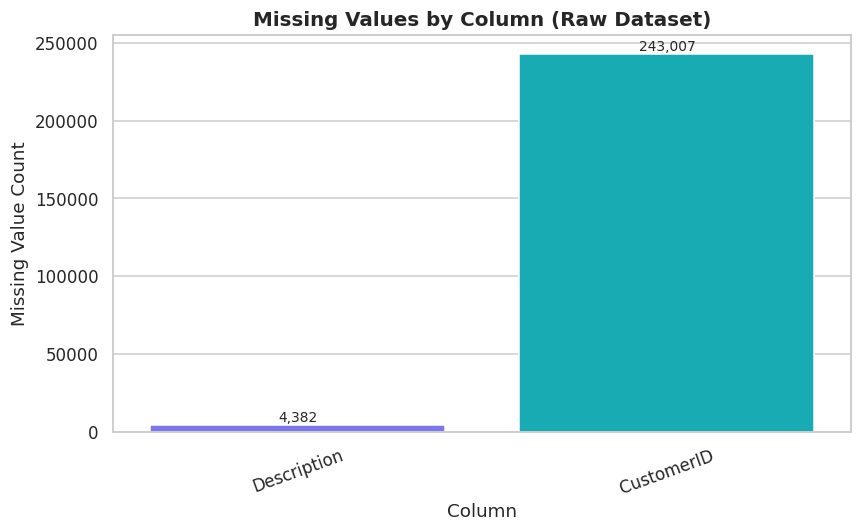

In [29]:
plt.figure(figsize=(8, 5))
sns.barplot(x=missing_df.index, y=missing_df["missing_count"], palette=PALETTE)
plt.title("Missing Values by Column (Raw Dataset)")
plt.xlabel("Column")
plt.ylabel("Missing Value Count")
plt.xticks(rotation=20)
for i, v in enumerate(missing_df["missing_count"]):
    plt.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/09_missing_values.png")
plt.show()

**Observations:**
- `CustomerID` is by far the largest source of missingness (**22.77%** of raw rows), which is why
  it was the biggest single driver of row removal during cleaning — these transactions cannot be
  attributed to a specific customer and are unusable for customer-level analytics.
- `Description` is missing in a very small share of rows (**0.41%**) and was recoverable via a
  `StockCode` lookup rather than requiring row removal.
- No other columns (`Invoice`, `StockCode`, `Quantity`, `InvoiceDate`, `Price`, `Country`) have any
  missing values, indicating those fields are reliably captured at the point of sale.

## E. Correlation Analysis

Correlation between the core numeric transaction fields on the cleaned dataset.

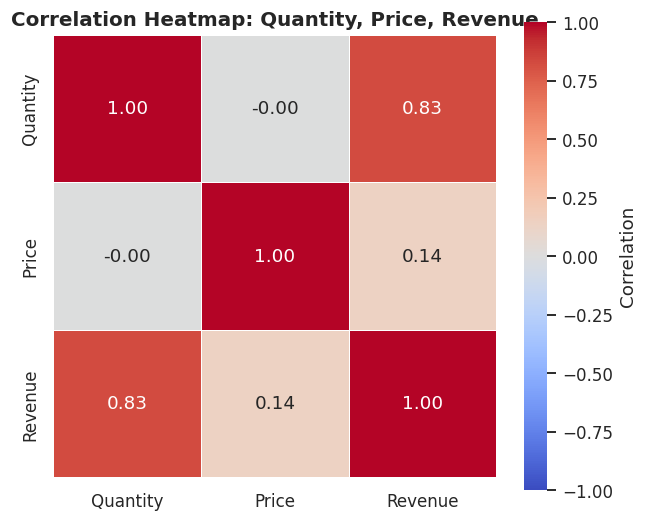

,Quantity,Price,Revenue
Quantity,1.000000,-0.004880,0.827162
Price,-0.004880,1.000000,0.135984
Revenue,0.827162,0.135984,1.000000


In [30]:
corr_cols = ["Quantity", "Price", "Revenue"]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True,
            linewidths=0.5, cbar_kws={"label": "Correlation"})
plt.title("Correlation Heatmap: Quantity, Price, Revenue")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/10_correlation_heatmap.png")
plt.show()

corr_matrix

**Relationships observed:**
- `Revenue` is strongly positively correlated with `Quantity` — expected, since `Revenue = Quantity × Price`
  and most transactions involve relatively low unit prices, so volume is the primary revenue driver.
- `Revenue` shows a much weaker correlation with `Price` alone, showing that high revenue is driven
  more by bulk purchases than by expensive individual items.
- `Quantity` and `Price` are weakly (near-zero to slightly negative) correlated, consistent with
  customers buying larger quantities of lower-priced, everyday gift items rather than fewer
  high-priced items.

## F. Dataset Preparation Summary

A readiness summary of the three datasets prepared for downstream AI/analytics modules.

In [31]:
prep_summary_df = pd.DataFrame(
    {
        "Dataset": ["clean_transactions.csv", "customer_dataset.csv", "inventory_dataset.csv"],
        "Records": [f"{len(df_export):,}", f"{len(customer_df):,}", f"{len(inventory_df):,}"],
        "Columns": [df_export.shape[1], customer_df.shape[1], inventory_df.shape[1]],
        "Purpose": [
            "Transaction-level, cleaned & feature-enriched data — the base table for all downstream analytics and AI modules",
            "Customer-level aggregates (orders, spend, product breadth, country) — foundation for future customer analytics modules",
            "Product-level aggregates (quantity sold, revenue, demand score, sales frequency) — foundation for future inventory/demand modules",
        ],
    }
)
prep_summary_df

,Dataset,Records,Columns,Purpose
0,clean_transactions.csv,"779,425",20,"Transaction-level, cleaned & feature-enriched ..."
1,customer_dataset.csv,"5,878",7,"Customer-level aggregates (orders, spend, prod..."
2,inventory_dataset.csv,"5,286",7,"Product-level aggregates (quantity sold, reven..."


## G. Business Insights

Ten descriptive, data-driven insights derived from the cleaned datasets. These are
observations to inform business decisions — not predictions or forecasts.

In [32]:
from IPython.display import Markdown, display

# --- Supporting calculations ---
top_month_row = df.groupby("YearMonth")["Revenue"].sum().idxmax()
top_month_val = df.groupby("YearMonth")["Revenue"].sum().max()

best_qty_product = inventory_df.sort_values("QuantitySold", ascending=False).iloc[0]
best_revenue_product = inventory_df.sort_values("Revenue", ascending=False).iloc[0]

top_customer_row = customer_df.iloc[0]

top_country_row = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).reset_index().iloc[0]
top_country_share = top_country_row["Revenue"] / df["Revenue"].sum() * 100

top_weekday = df.groupby("DayOfWeek")["Revenue"].sum().idxmax()

cust_sorted = customer_df.sort_values("TotalRevenue", ascending=False).reset_index(drop=True)
top10pct_n = max(1, int(len(cust_sorted) * 0.10))
top10pct_share = cust_sorted.head(top10pct_n)["TotalRevenue"].sum() / cust_sorted["TotalRevenue"].sum() * 100

avg_orders_per_customer = customer_df["TotalOrders"].mean()

low_frequency_products = (inventory_df["SalesFrequency"] <= 5).sum()
low_frequency_share = low_frequency_products / len(inventory_df) * 100

n_countries = df["Country"].nunique()

insights_md = f"""
1. **Highest revenue month:** `{top_month_row}` generated the highest monthly revenue at
   **£{top_month_val:,.0f}**, pointing to a strong pre-holiday-season buying pattern.

2. **Best-selling product (by volume):** *{best_qty_product['ProductName']}*
   ({best_qty_product['QuantitySold']:,.0f} units sold) — a strong candidate for guaranteed
   stock availability.

3. **Highest-revenue product:** *{best_revenue_product['ProductName']}*
   (£{best_revenue_product['Revenue']:,.0f} in revenue) — the flagship SKU by commercial value.

4. **Highest-revenue customer:** Customer **{top_customer_row['CustomerID']}**
   contributed **£{top_customer_row['TotalRevenue']:,.0f}** in total revenue, a strong
   candidate for a VIP/wholesale account program.

5. **Country contributing maximum revenue:** **{top_country_row['Country']}** accounts for
   **{top_country_share:.1f}%** of total revenue, showing the business is heavily concentrated
   in a single market.

6. **Seasonal sales pattern:** Revenue peaks in the final quarter of the calendar year
   (see Monthly Seasonality chart) and is highest on **{top_weekday}s** during the week —
   useful for staffing and inventory timing.

7. **Revenue concentration:** The top 10% of customers ({top10pct_n:,} customers) generate
   **{top10pct_share:.1f}%** of total revenue — a classic Pareto pattern that supports
   targeted retention efforts for a relatively small customer group.

8. **Customer purchasing behaviour:** On average, each customer places
   **{avg_orders_per_customer:,.1f} orders** over the observed period, indicating a
   repeat-purchase, relationship-driven customer base rather than one-off buyers.

9. **Inventory observations:** **{low_frequency_products:,} products ({low_frequency_share:.1f}%
   of the catalog)** appear in 5 or fewer invoices, suggesting a long tail of slow-moving SKUs
   that may be candidates for catalog rationalization.

10. **Business opportunity:** With sales spread across **{n_countries} countries** but heavily
    weighted to one market, there is a clear opportunity to grow international demand —
    balanced against the operational recommendation to protect stock levels of the top-selling
    and highest-revenue products identified above ahead of peak season.
"""

display(Markdown(insights_md))


1. **Highest revenue month:** `2010-11` generated the highest monthly revenue at
   **£1,166,460**, pointing to a strong pre-holiday-season buying pattern.

2. **Best-selling product (by volume):** *WORLD WAR 2 GLIDERS ASSTD DESIGNS*
   (105,185 units sold) — a strong candidate for guaranteed
   stock availability.

3. **Highest-revenue product:** *REGENCY CAKESTAND 3 TIER*
   (£277,656 in revenue) — the flagship SKU by commercial value.

4. **Highest-revenue customer:** Customer **18102**
   contributed **£580,987** in total revenue, a strong
   candidate for a VIP/wholesale account program.

5. **Country contributing maximum revenue:** **United Kingdom** accounts for
   **82.8%** of total revenue, showing the business is heavily concentrated
   in a single market.

6. **Seasonal sales pattern:** Revenue peaks in the final quarter of the calendar year
   (see Monthly Seasonality chart) and is highest on **Thursdays** during the week —
   useful for staffing and inventory timing.

7. **Revenue concentration:** The top 10% of customers (587 customers) generate
   **63.9%** of total revenue — a classic Pareto pattern that supports
   targeted retention efforts for a relatively small customer group.

8. **Customer purchasing behaviour:** On average, each customer places
   **6.3 orders** over the observed period, indicating a
   repeat-purchase, relationship-driven customer base rather than one-off buyers.

9. **Inventory observations:** **704 products (13.3%
   of the catalog)** appear in 5 or fewer invoices, suggesting a long tail of slow-moving SKUs
   that may be candidates for catalog rationalization.

10. **Business opportunity:** With sales spread across **41 countries** but heavily
    weighted to one market, there is a clear opportunity to grow international demand —
    balanced against the operational recommendation to protect stock levels of the top-selling
    and highest-revenue products identified above ahead of peak season.


## H. Export Files — Confirmation

The three processed datasets and all EDA/diagnostic charts were exported as part of this
notebook's execution. This section confirms what was written to disk.

In [33]:
import os

export_files = [
    (f"{PROCESSED_DIR}/clean_transactions.csv", "Processed Data"),
    (f"{PROCESSED_DIR}/customer_dataset.csv", "Processed Data"),
    (f"{PROCESSED_DIR}/inventory_dataset.csv", "Processed Data"),
]

chart_files = sorted(f for f in os.listdir(CHARTS_DIR) if f.endswith(".png"))

export_status = []
for path, category in export_files:
    exists = os.path.exists(path)
    size_kb = os.path.getsize(path) / 1024 if exists else 0
    export_status.append({"File": os.path.basename(path), "Category": category,
                           "Status": "Exported" if exists else "Missing", "Size (KB)": f"{size_kb:,.0f}"})

export_status_df = pd.DataFrame(export_status)
print(f"Charts saved in '{CHARTS_DIR}/': {len(chart_files)} files")
for c in chart_files:
    print("  -", c)
print()
export_status_df

Charts saved in '../charts/': 10 files
  - 01_monthly_sales_trend.png
  - 02_top_10_products.png
  - 03_top_10_customers.png
  - 04_country_wise_sales.png
  - 05_revenue_distribution.png
  - 06_quantity_distribution.png
  - 07_sales_by_month.png
  - 08_sales_by_weekday.png
  - 09_missing_values.png
  - 10_correlation_heatmap.png



,File,Category,Status,Size (KB)
0,clean_transactions.csv,Processed Data,Exported,"117,761"
1,customer_dataset.csv,Processed Data,Exported,248
2,inventory_dataset.csv,Processed Data,Exported,327


## I. Recommended Project Folder Structure

```
MarketMind_AI_Project/
│
├── data/
│   ├── raw/                     # Original Online Retail II source data
│   └── processed/                # clean_transactions.csv, customer_dataset.csv, inventory_dataset.csv
│
├── notebooks/
│   └── data_preprocessing.ipynb  # This notebook
│
├── charts/                       # All EDA & diagnostic visualizations (PNG)
│
├── reports/
│   ├── data_quality_report.md
│   ├── cleaning_log.md
│   └── preprocessing_report.md
│
└── README.md
```


## J. Conclusion

This milestone transformed a raw, imperfect transaction log of over one million rows into a
trustworthy, analysis-ready foundation for the MarketMind AI platform.

**Data quality improvements:** duplicate records, cancelled transactions, unattributable rows
(missing `CustomerID`), and invalid pricing were systematically identified and removed, while
recoverable gaps (missing descriptions) were resolved rather than discarded — leaving a clean
dataset of 779,425 verified transaction records.

**Business understanding gained:** the KPI and insight sections above surface a business that is
revenue-concentrated in the UK, driven by a relatively small set of high-value customers and
flagship products, with a clear seasonal peak ahead of the holidays — all valuable context for
prioritizing future analysis.

**Dataset readiness:** the three exported datasets — transaction-level, customer-level, and
product-level — are each structured, deduplicated, and enriched with the business features needed
for the next stages of the platform, without embedding any assumptions about future modeling
approaches.

**Importance of preprocessing:** the scale of issues found (missing IDs, cancellations, duplicates)
confirms that skipping this stage would have propagated significant noise into every downstream
analysis — this milestone is the foundation the rest of the platform depends on.

**Supporting future AI modules:** because `clean_transactions.csv`, `customer_dataset.csv`, and
`inventory_dataset.csv` are already clean, deduplicated, and feature-enriched, later milestones can
build directly on top of them without repeating this data preparation work.
